In [1]:
import pandas as pd

variant_info_df = pd.read_pickle("variant_info_df.pkl")

In [46]:
variant_info_df

,Chromosome,Start,ID,REF,ALT,QUAL,FILTER,AC_joint,AN_joint,AF_joint,...,gained,lost,unchanged,NCPR_change,FCR_change,hydropathy_change,kappa_change,pos_count_change,neg_count_change,aromaticity_change
0,chr1,7784882,.,C,T,.,PASS,9,1506442,5.974340e-06,...,0,0,2,0.000000,0.000000,0.450000,0.000000,0.0,0.0,0.0
1,chr1,7784883,.,C,T,.,PASS,2,1508626,1.325710e-06,...,0,0,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,chr1,7784884,.,C,A,.,PASS,1,1508688,6.628280e-07,...,0,1,1,-0.083333,-0.083333,0.308333,0.386084,-1.0,0.0,0.0
3,chr1,7784884,.,C,G,.,PASS,3,1508690,1.988480e-06,...,0,1,1,-0.083333,-0.083333,0.341667,0.386084,-1.0,0.0,0.0
4,chr1,7784884,.,C,T,.,PASS,52,1508690,3.446700e-05,...,0,1,1,-0.083333,-0.083333,0.583333,0.386084,-1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14275,chrY,12912737,.,C,T,.,PASS,1,397930,2.513000e-06,...,0,0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14276,chrY,12912738,.,G,A,.,EXOMES_FILTERED,3,398048,7.536780e-06,...,0,0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14277,chrY,12912739,.,T,C,.,PASS,1,398402,2.510030e-06,...,0,0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14278,chrY,12912740,.,G,A,.,EXOMES_FILTERED,2,398315,5.021150e-06,...,0,0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


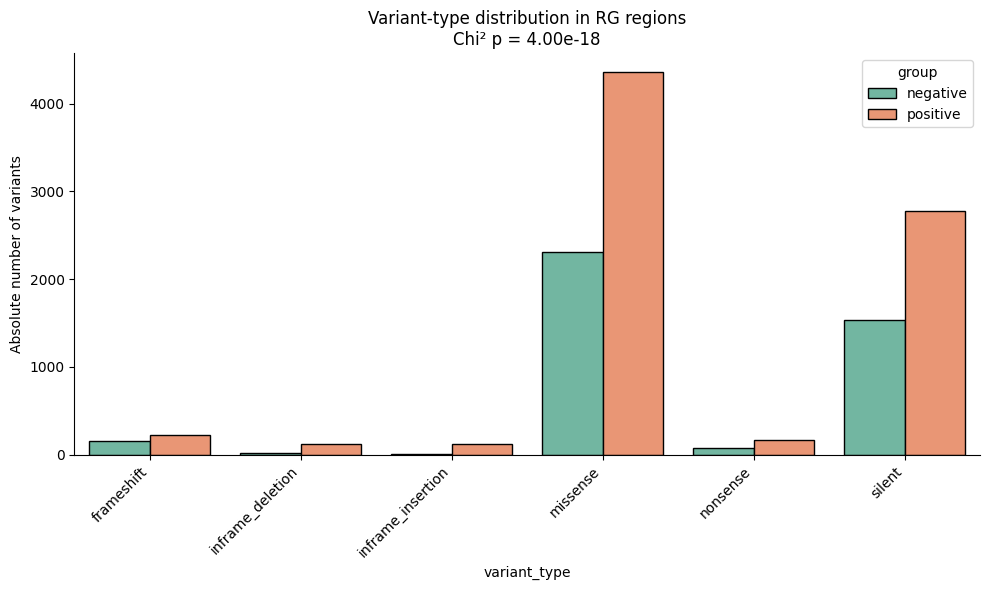

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# -------------------
# Prepare data
# -------------------
df_plot = (
    variant_info_df.groupby(["group", "variant_type"])
      .size()
      .reset_index(name="count")
)

# Convert counts to proportions within each group
df_plot["prop"] = df_plot.groupby("group")["count"].transform(lambda x: x / x.sum())

# -------------------
# Chi² test
# -------------------
cont_table = (
    variant_info_df.groupby(["group", "variant_type"])
      .size()
      .unstack(fill_value=0)
)
chi2, p, dof, expected = chi2_contingency(cont_table)

# -------------------
# Plot
# -------------------
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_plot,
    x="variant_type",
    y="count",
    hue="group",
    palette="Set2",
    edgecolor="black"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Absolute number of variants")
plt.title(f"Variant-type distribution in RG regions\nChi² p = {p:.2e}")

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_625/985020985.py:7: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  variant_info_df.groupby(["group", "variant_type"])


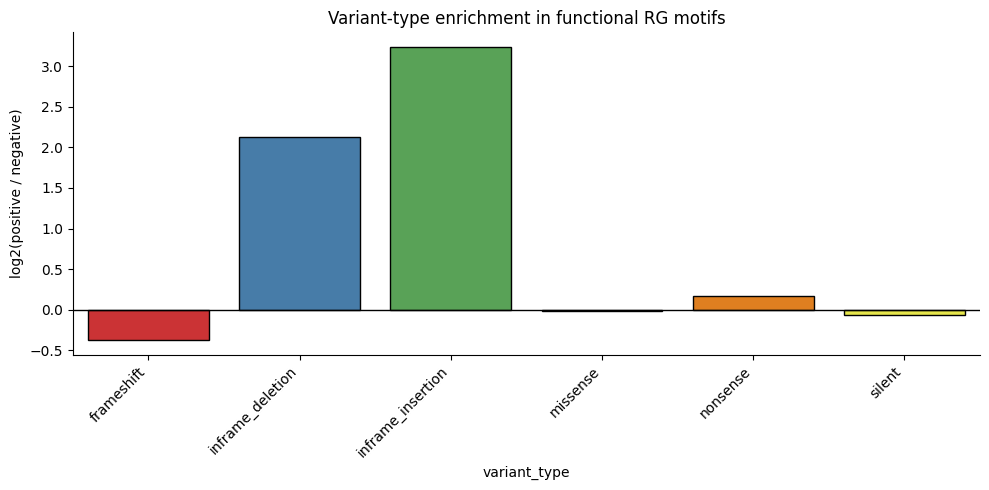

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare proportions
prop = (
    variant_info_df.groupby(["group", "variant_type"])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
      .unstack()
)

log2_enrich = np.log2(prop.loc["positive"] / prop.loc["negative"])

# Plot
plt.figure(figsize=(10,5))
sns.barplot(
    x=log2_enrich.index,
    y=log2_enrich.values,
    palette="Set1",
    edgecolor="black"
)

plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("log2(positive / negative)")
plt.title("Variant-type enrichment in functional RG motifs")

sns.despine()
plt.tight_layout()
plt.show()

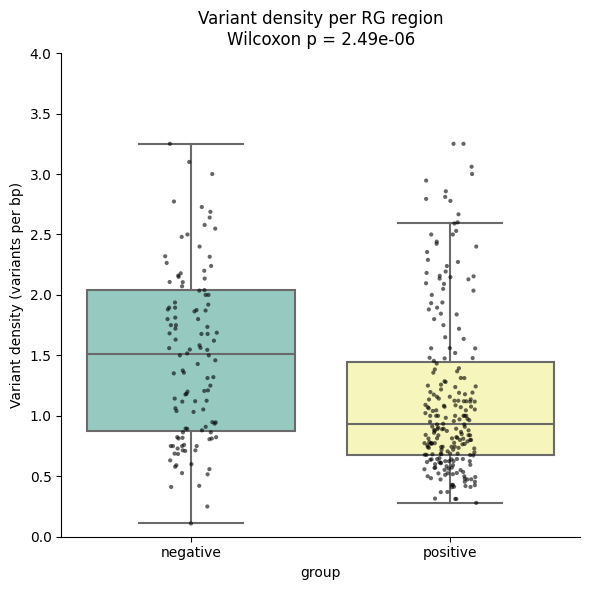

In [4]:
from scipy.stats import ranksums

# -------------------------
# Prepare per-region data
# -------------------------
# Region lengths
region_len = (
    variant_info_df.groupby("region_id")[["Start_b","End_b"]]
      .first()
)
region_len["region_length"] = region_len["End_b"] - region_len["Start_b"] + 1
region_len = region_len["region_length"]

# Variant counts
region_counts = (
    variant_info_df.groupby(["region_id", "group"])
      .size()
      .reset_index(name="count")
)

# Merge
region_data = region_counts.merge(region_len, on="region_id")
region_data["density"] = region_data["count"] / region_data["region_length"]

# -------------------------
# Wilcoxon rank-sum test
# -------------------------
pos = region_data.loc[region_data["group"] == "positive", "density"]
neg = region_data.loc[region_data["group"] == "negative", "density"]

stat, p = ranksums(pos, neg)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(6,6))
sns.boxplot(
    data=region_data,
    x="group",
    y="density",
    palette="Set3",
    showfliers=False
)
sns.stripplot(
    data=region_data,
    x="group",
    y="density",
    color="black",
    size=3,
    jitter=True,
    alpha=0.6
)

plt.title(f"Variant density per RG region\nWilcoxon p = {p:.2e}")
plt.ylabel("Variant density (variants per bp)")
plt.ylim(0,4)
sns.despine()
plt.tight_layout()
plt.show()


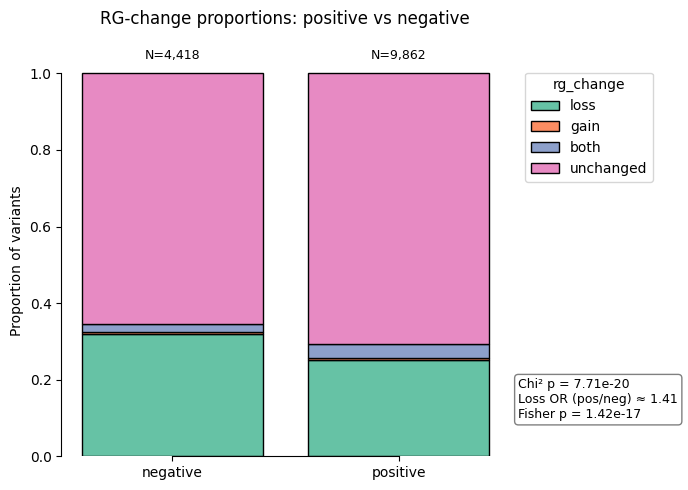

Contingency table (counts):
rg_change  loss  gain  both  unchanged
group                                 
negative   1413    21    93       2891
positive   2470    61   369       6962

Chi²: 92.11113023908143 p: 7.710077397329844e-20
Loss 2x2 table (pos_loss, pos_no; neg_loss, neg_no): 1413 3005 2470 7392
Odds ratio (Haldane corrected if needed): 1.407222240934475 Fisher p: 1.4223262475735222e-17


In [5]:
# Block A: Aggregated RG-change comparison
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact

# --- Prepare dataframe (df is your dataframe) ---
# Create a single categorical rg_change per variant.
# Rules:
# - 'loss' if lost>0 and gained==0
# - 'gain' if gained>0 and lost==0
# - 'both' if gained>0 and lost>0
# - 'unchanged' if gained==0 and lost==0 and unchanged>0 or all zero
def classify_rg_change(row):
    g = int(row.get("gained", 0))
    l = int(row.get("lost", 0))
    u = int(row.get("unchanged", 0))
    if l > 0 and g == 0:
        return "loss"
    elif g > 0 and l == 0:
        return "gain"
    elif g > 0 and l > 0:
        return "both"
    else:
        # no gain or loss -> unchanged (or ambiguous)
        return "unchanged"

df = variant_info_df.copy()
df["rg_change"] = df.apply(classify_rg_change, axis=1)

# Keep only expected groups
df = df[df["group"].isin(["positive", "negative"])]

# Compute contingency (2 x 3)
cont_table = pd.crosstab(df["group"], df["rg_change"])
# Ensure columns in consistent order
order = ["loss", "gain", "both", "unchanged"]
for c in order:
    if c not in cont_table.columns:
        cont_table[c] = 0
cont_table = cont_table[order]

# Chi-square test across the full 2 x (k) table
chi2, chi_p, dof, expected = chi2_contingency(cont_table.values)

# For odds ratio of LOSS specifically (2x2): positive vs negative for loss presence
# Build 2x2 table: rows groups, cols [loss_present, loss_absent]
loss_present = cont_table["loss"]
loss_absent = cont_table.drop(columns=["loss"]).sum(axis=1)
table_2x2 = np.array([loss_present.values, loss_absent.values]).T  # shape (2,2)

# SciPy fisher_exact expects shape (2,2) with rows/cols
# Reorder: [[pos_loss, pos_noloss],[neg_loss, neg_noloss]]
pos_loss = int(table_2x2[0,0])
pos_noloss = int(table_2x2[0,1])
neg_loss = int(table_2x2[1,0])
neg_noloss = int(table_2x2[1,1])
# apply Haldane-Anscombe correction if any zero (add 0.5)
a = pos_loss + 0.5 if 0 in (pos_loss, pos_noloss, neg_loss, neg_noloss) else pos_loss
b = pos_noloss + 0.5 if 0 in (pos_loss, pos_noloss, neg_loss, neg_noloss) else pos_noloss
c = neg_loss + 0.5 if 0 in (pos_loss, pos_noloss, neg_loss, neg_noloss) else neg_loss
d = neg_noloss + 0.5 if 0 in (pos_loss, pos_noloss, neg_loss, neg_noloss) else neg_noloss

odds_ratio = (a * d) / (b * c)
# Fisher exact on raw integers
try:
    fisher_odds, fisher_p = fisher_exact(np.array([[pos_loss, pos_noloss],[neg_loss, neg_noloss]]))
except Exception:
    fisher_odds, fisher_p = np.nan, np.nan

# --- Plot: stacked proportional bars ---
prop = cont_table.div(cont_table.sum(axis=1), axis=0)  # proportions per group
prop = prop[order]  # ensure order

fig, ax = plt.subplots(figsize=(7,5))
bottom = np.zeros(len(prop))
groups = prop.index.tolist()
x = np.arange(len(groups))

colors = sns.color_palette("Set2", n_colors=len(order))
for i, col in enumerate(order):
    ax.bar(x, prop[col].values, bottom=bottom, label=col, color=colors[i], edgecolor='k')
    bottom += prop[col].values

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylim(0,1.02)
ax.set_ylabel("Proportion of variants")
ax.set_title("RG-change proportions: positive vs negative",pad=30)
ax.legend(title="rg_change", bbox_to_anchor=(1.02, 1), loc="upper left")

# Annotate counts on each bar (N total per group)
group_counts = cont_table.sum(axis=1)
for i, g in enumerate(groups):
    ax.text(i, 1.03, f"N={group_counts.loc[g]:,}", ha="center", va="bottom", fontsize=9)

# Annotate chi-square and OR
txt = f"Chi² p = {chi_p:.2e}\nLoss OR (pos/neg) ≈ {odds_ratio:.2f}\nFisher p = {fisher_p:.2e}"
ax.text(1.02, 0.2, txt, transform=ax.transAxes, fontsize=9, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

sns.despine(trim=True)
plt.tight_layout()
plt.show()

# Print contingency table for inspection
print("Contingency table (counts):")
print(cont_table)
print("\nChi²:", chi2, "p:", chi_p)
print("Loss 2x2 table (pos_loss, pos_no; neg_loss, neg_no):", pos_loss, pos_noloss, neg_loss, neg_noloss)
print("Odds ratio (Haldane corrected if needed):", odds_ratio, "Fisher p:", fisher_p)


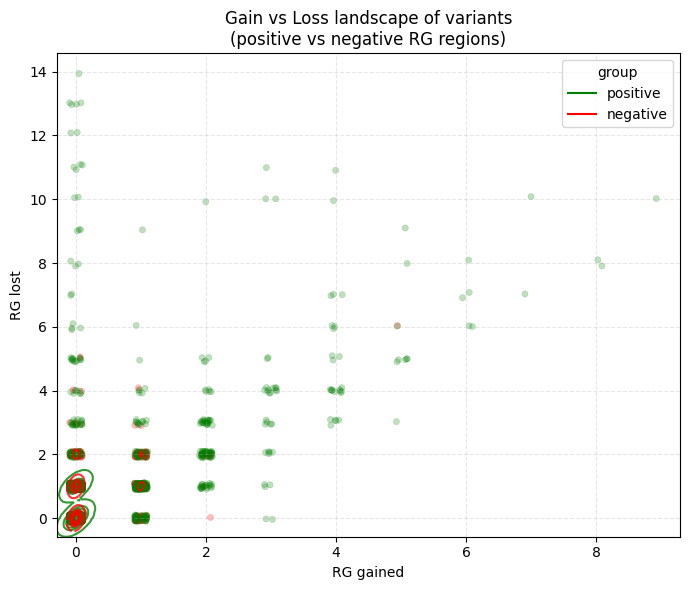

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df2 = variant_info_df.copy()

# Ensure gained & lost are integers
df2["gained"] = df2["gained"].astype(int)
df2["lost"] = df2["lost"].astype(int)

# Jitter function to avoid perfect overlaps
def jitter(arr, scale=0.1):
    return arr + np.random.uniform(-scale, scale, size=len(arr))

plt.figure(figsize=(7,6))

# KDE contours: smooth estimate of densities
sns.kdeplot(
    data=df2, x="gained", y="lost", hue="group",
    fill=False, levels=6, linewidths=1.5,
    palette={"positive":"green","negative":"red"},
    alpha=0.8
)

# Jittered scatter overlay
sns.scatterplot(
    x=jitter(df2["gained"]), y=jitter(df2["lost"]),
    hue=df2["group"],
    palette={"positive":"green","negative":"red"},
    alpha=0.25, s=20, edgecolor=None, legend=False
)

plt.xlabel("RG gained")
plt.ylabel("RG lost")
plt.title("Gain vs Loss landscape of variants\n(positive vs negative RG regions)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


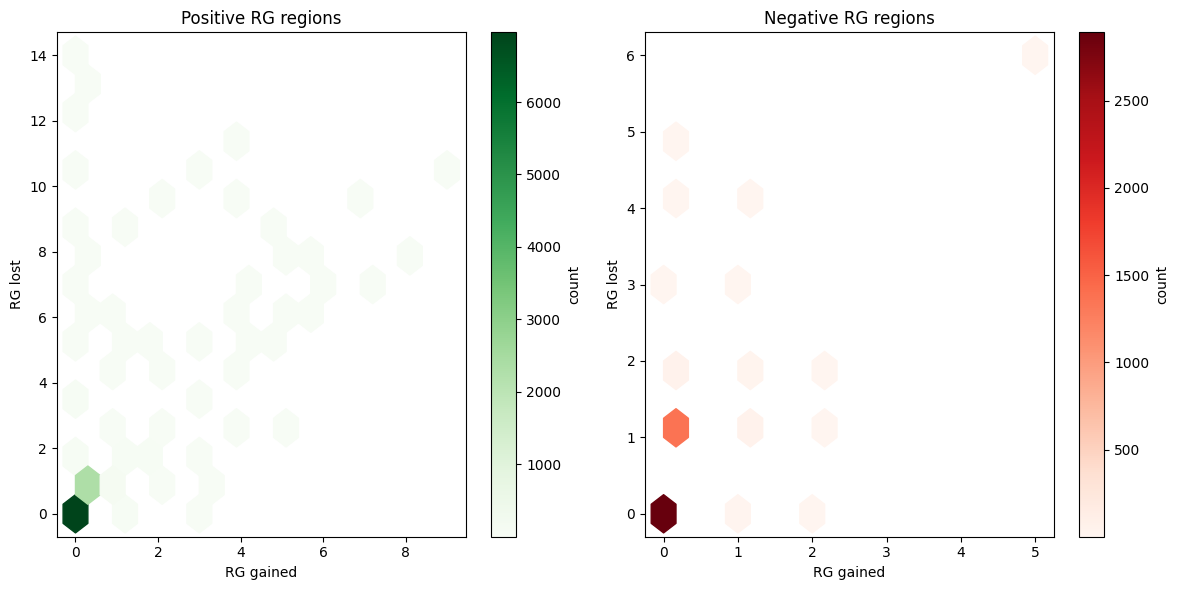

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,6))

for ax, grp, cmap in zip(
    axes,
    ["positive","negative"],
    ["Greens","Reds"]
):
    sub = df2[df2["group"] == grp]

    hb = ax.hexbin(
        sub["gained"], sub["lost"],
        gridsize=15, cmap=cmap, mincnt=1
    )

    ax.set_title(f"{grp.capitalize()} RG regions")
    ax.set_xlabel("RG gained")
    ax.set_ylabel("RG lost")
    fig.colorbar(hb, ax=ax, label="count")

plt.tight_layout()
plt.show()

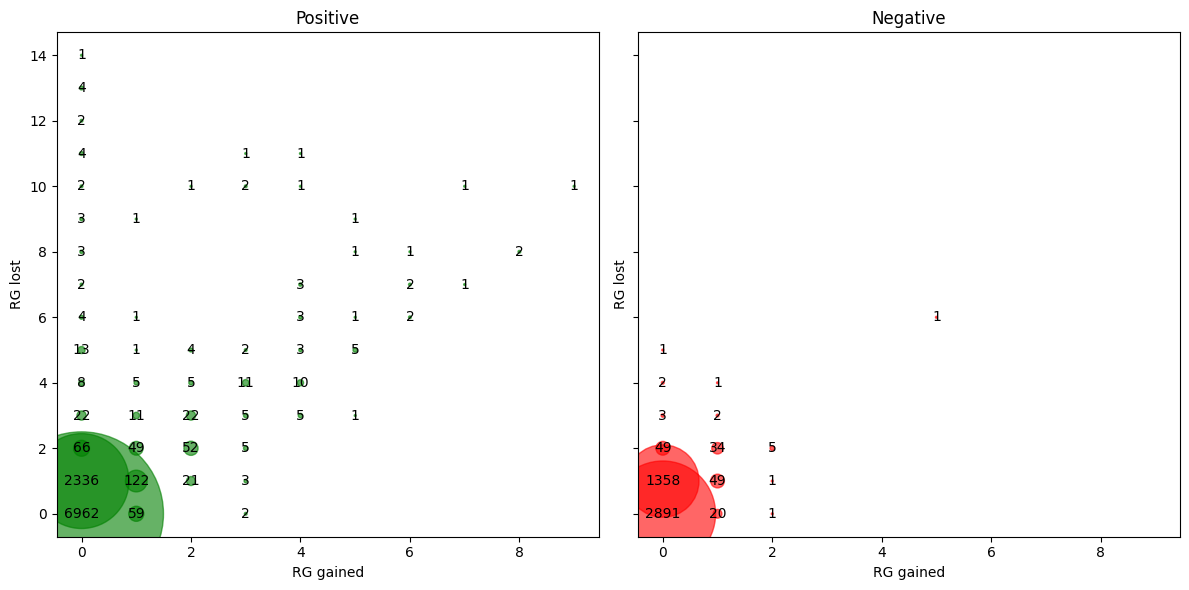

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(12,6), sharex=True, sharey=True)

for ax, grp, color in zip(
    axes,
    ["positive","negative"],
    ["green","red"]
):

    sub = df2[df2["group"] == grp]

    ct = sub.groupby(["gained","lost"]).size().reset_index(name="count")

    ax.scatter(
        ct["gained"], ct["lost"],
        s=ct["count"]*2,
        color=color, alpha=0.6
    )

    for _, r in ct.iterrows():
        ax.text(r["gained"], r["lost"], str(r["count"]), ha="center", va="center")

    ax.set_title(f"{grp.capitalize()}")
    ax.set_xlabel("RG gained")
    ax.set_ylabel("RG lost")

plt.tight_layout()
plt.show()

['missense', 'silent', 'frameshift', 'nonsense', 'inframe_insertion', 'inframe_deletion']


/tmp/ipykernel_9518/3027473201.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  gridsize=15, cmap=plt.cm.get_cmap('Greens' if grp=='positive' else 'Reds'),
/tmp/ipykernel_9518/3027473201.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  gridsize=15, cmap=plt.cm.get_cmap('Greens' if grp=='positive' else 'Reds'),
/home/eric/anaconda3/envs/biopy/lib/python3.8/site-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_9518/3027473201.py:52: MatplotlibDeprecationWarning: The get_cmap function was 

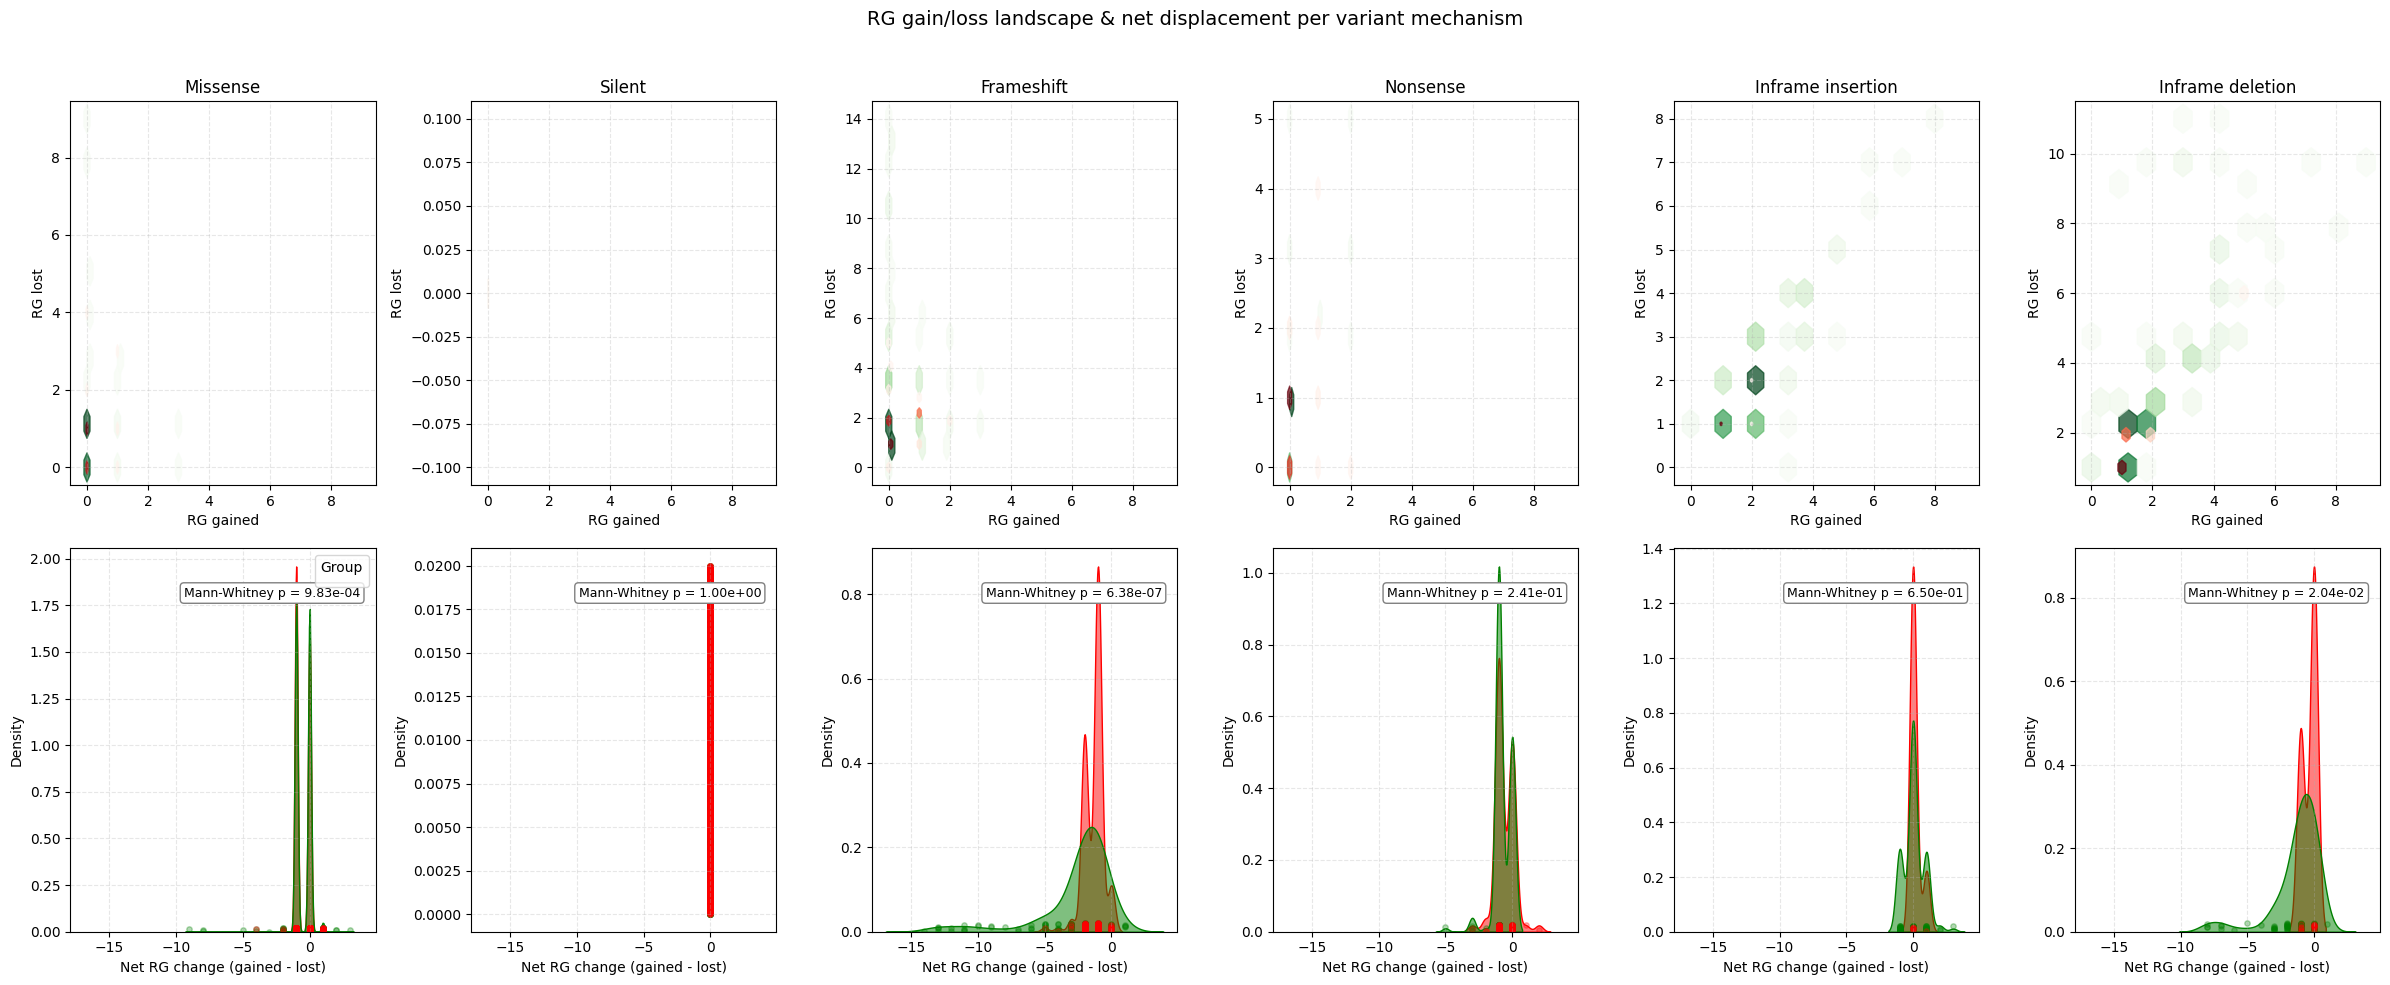

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# Copy df to avoid modifying original
df_plot = variant_info_df.copy()

# Ensure integer columns
df_plot["gained"] = df_plot["gained"].astype(int)
df_plot["lost"] = df_plot["lost"].astype(int)

# Collapse variant_type into three mechanistic bins (same as before)
mech_map = {
    "nonsense": "truncating",
    "frameshift": "truncating",
    "inframe_insertion": "inframe_structural",
    "inframe_deletion": "inframe_structural",
    "complex": "inframe_structural",
    "missense": "substitution",
    "silent": "substitution"
}
df_plot["variant_mech"] = df_plot["variant_type"].map(mech_map).fillna("other")

# Compute net displacement: gained - lost
df_plot["net_rg"] = df_plot["gained"] - df_plot["lost"]

# Define plotting order
mech_order = ["truncating", "inframe_structural", "substitution", "other"]
group_order = ["positive", "negative"]
colors = {"positive": "green", "negative": "red"}

# Create figure layout: hexbin on top row, net displacement below row, per mechanism
# n_mech = len(mech_order)
mech_order = [x for x in df_plot["variant_type"].unique() if x is not None]
# mech_order.remove(None)
print(mech_order)
n_mech = len(mech_order)
fig, axes = plt.subplots(2, n_mech, figsize=(4*n_mech, 10), sharex='row', sharey=False)

for i, mech in enumerate(mech_order):
    sub = df_plot[df_plot["variant_type"] == mech]
    
    # --- Top row: Hexbin 2D counts (gained vs lost)
    ax = axes[0, i]
    for grp in group_order:
        subgrp = sub[sub["group"] == grp]
        if not subgrp.empty:
            hb = ax.hexbin(
                subgrp["gained"], subgrp["lost"],
                gridsize=15, cmap=plt.cm.get_cmap('Greens' if grp=='positive' else 'Reds'),
                mincnt=1, alpha=0.7
            )
    ax.set_title(f"{mech.replace('_',' ').capitalize()}")
    ax.set_xlabel("RG gained")
    ax.set_ylabel("RG lost")
    ax.grid(True, linestyle="--", alpha=0.3)

   # --- Bottom row: Net displacement distribution
    ax = axes[1, i]

    # KDE
    sns.kdeplot(
        data=sub, x="net_rg", hue="group",
        fill=True, common_norm=False, palette=colors, alpha=0.5, ax=ax
    )

    # Overlay individual points using scatterplot with jitter
    for j, grp in enumerate(group_order):
        subgrp = sub[sub["group"] == grp]
        if not subgrp.empty:
            y_jitter = np.random.uniform(0, 0.02, size=len(subgrp))  # small vertical jitter
            ax.scatter(
                subgrp["net_rg"], y_jitter,
                color=colors[grp], alpha=0.3, s=15, label=None
            )
    ax.set_xlabel("Net RG change (gained - lost)")
    ax.set_ylabel("Density")
    ax.grid(True, linestyle="--", alpha=0.3)
    
    # --- Mann-Whitney U test per mechanism
    pos_vals = sub[sub["group"]=="positive"]["net_rg"]
    neg_vals = sub[sub["group"]=="negative"]["net_rg"]
    if len(pos_vals) > 0 and len(neg_vals) > 0:
        stat, pval = mannwhitneyu(pos_vals, neg_vals, alternative='two-sided')
        ax.text(0.95, 0.9, f"Mann-Whitney p = {pval:.2e}", transform=ax.transAxes,
                ha='right', va='top', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))
    else:
        ax.text(0.95, 0.9, f"Not enough data", transform=ax.transAxes,
                ha='right', va='top', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

# Remove duplicate legends in bottom row
for ax in axes[1,1:]:
    ax.get_legend().remove()
axes[1,0].legend(title="Group")

plt.suptitle("RG gain/loss landscape & net displacement per variant mechanism", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'unchanged', 'gain', 'both', 'loss'}


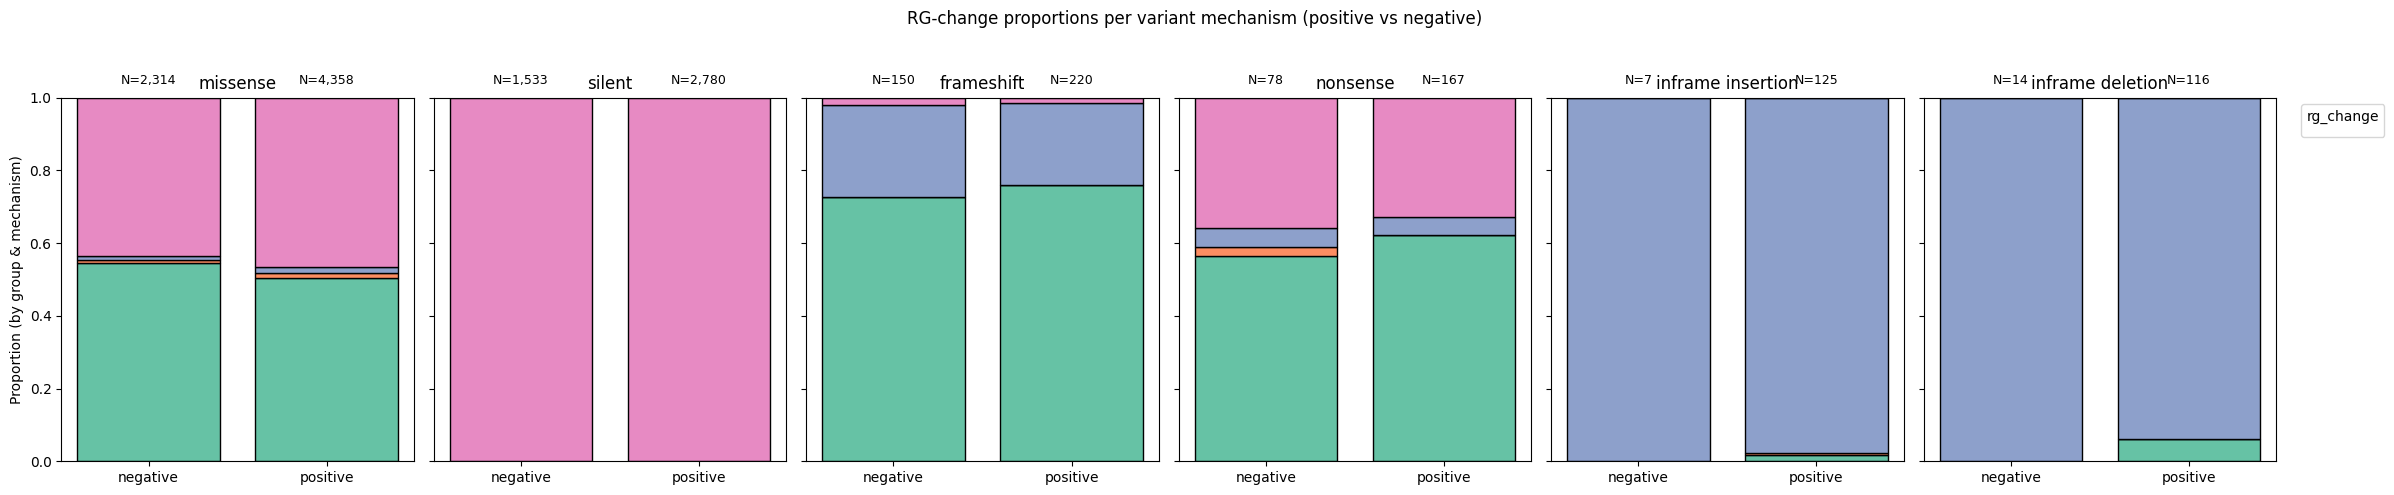

In [59]:
# Block B: Mechanism-aware RG-change comparison
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact

# Copy df to avoid side effects
df2 = variant_info_df.copy()

# Map variant_type -> mechanism bins
mech_map = {
    # truncating
    "nonsense": "truncating",
    "frameshift": "truncating",
    # in-frame structural
    "inframe_insertion": "inframe_structural",
    "inframe_deletion": "inframe_structural",
    "complex": "inframe_structural",
    # substitutions
    "missense": "substitution",
    "silent": "substitution"
}
# Default: put any other types into "other"
df2["variant_mech"] = df2["variant_type"].map(mech_map).fillna("other")

# If 'other' is very small, you may drop or keep it
# Create rg_change if not already (we did in Block A, but safe to redo)
df2["rg_change"] = df2.apply(classify_rg_change, axis=1)

# Define order for plotting
# mech_order = ["truncating", "inframe_structural", "substitution", "other"]
mech_order = [x for x in df_plot["variant_type"].unique() if x is not None]
rg_order = ["loss", "gain", "both", "unchanged"]

# Aggregate counts: group x variant_mech x rg_change
agg = (
    df2.groupby(["group", "variant_type", "rg_change"])
       .size()
       .reset_index(name="count")
)
# Ensure 0s for missing combos
all_idx = pd.MultiIndex.from_product([["positive","negative"], mech_order, rg_order], names=["group","variant_type","rg_change"])
agg = agg.set_index(["group","variant_type","rg_change"]).reindex(all_idx, fill_value=0).reset_index()

# Compute proportions within each (group, mech) for stacked bars
agg["total_by_group_mech"] = agg.groupby(["group","variant_type"])["count"].transform("sum")
agg["prop"] = agg["count"] / agg["total_by_group_mech"].replace(0, np.nan)

# --- Plot: For each mechanism, show paired stacked bars (positive vs negative) ---
n_mech = len(mech_order)
fig, axes = plt.subplots(1, n_mech, figsize=(4*n_mech, 5), sharey=True)

colors = sns.color_palette("Set2", n_colors=len(rg_order))

# Keep track of which labels are already used
used_labels = set()

for ax, mech in zip(axes, mech_order):
    df_plot = agg[agg["variant_type"] == mech].copy()
    pivot = df_plot.pivot(index="group", columns="rg_change", values="prop").fillna(0)[rg_order]
    bottom = np.zeros(len(pivot))
    x = np.arange(len(pivot))
    
    for i, col in enumerate(rg_order):
        # Only add label if not already used
        label = col if col not in used_labels else None
        ax.bar(x, pivot[col].values, bottom=bottom, color=colors[i], edgecolor='k', label=label)
        bottom += pivot[col].values
        used_labels.add(col)
    
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index.tolist())
    ax.set_title(mech.replace("_"," "))
    if ax is axes[0]:
        ax.set_ylabel("Proportion (by group & mechanism)")
    
    # Annotate N per bar
    tot = df_plot.groupby("group")["total_by_group_mech"].first()
    for i, g in enumerate(pivot.index):
        n = int(tot.loc[g]) if g in tot.index else 0
        ax.text(i, 1.03, f"N={n:,}", ha="center", va="bottom", fontsize=9)
print(used_labels)
# for ax, mech in zip(axes, mech_order):
#     df_plot = agg[agg["variant_type"] == mech].copy()
#     # pivot to groups x rg_change
#     pivot = df_plot.pivot(index="group", columns="rg_change", values="prop").fillna(0)[rg_order]
#     bottom = np.zeros(len(pivot))
#     x = np.arange(len(pivot))
#     for i, col in enumerate(rg_order):
#         ax.bar(x, pivot[col].values, bottom=bottom, color=colors[i], edgecolor='k', label=col if mech==mech_order[0] else "")
#         bottom += pivot[col].values
#     ax.set_xticks(x)
#     ax.set_xticklabels(pivot.index.tolist())
#     ax.set_title(mech.replace("_"," "))
#     if ax is axes[0]:
#         ax.set_ylabel("Proportion (by group & mechanism)")
#     # annotate N per bar
#     tot = df_plot.groupby("group")["total_by_group_mech"].first()
#     for i, g in enumerate(pivot.index):
#         n = int(tot.loc[g]) if g in tot.index else 0
#         ax.text(i, 1.03, f"N={n:,}", ha="center", va="bottom", fontsize=9)

# Legend (once)
axes[-1].legend(title="rg_change", bbox_to_anchor=(1.05, 1), loc="upper left")
# axes[-1].legend()
plt.suptitle("RG-change proportions per variant mechanism (positive vs negative)")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

# # --- Per-mechanism Fisher exact test for LOSS presence (pos vs neg) ---
# results = []
# for mech in mech_order:
#     sub = agg[agg["variant_type"] == mech].copy()
#     # counts for loss present vs absent, per group
#     pos_loss = int(sub[(sub["group"]=="positive") & (sub["rg_change"]=="loss")]["count"].sum())
#     pos_nonloss = int(sub[(sub["group"]=="positive") & (sub["rg_change"]!="loss")]["count"].sum())
#     neg_loss = int(sub[(sub["group"]=="negative") & (sub["rg_change"]=="loss")]["count"].sum())
#     neg_nonloss = int(sub[(sub["group"]=="negative") & (sub["rg_change"]!="loss")]["count"].sum())
#     # 2x2 table
#     table = np.array([[pos_loss, pos_nonloss],[neg_loss, neg_nonloss]])
#     # Use Fisher's exact (works for small counts)
#     try:
#         or_val, pval = fisher_exact(table)
#     except Exception:
#         or_val, pval = np.nan, np.nan
#     results.append({
#         "mechanism": mech,
#         "pos_loss": pos_loss,
#         "pos_nonloss": pos_nonloss,
#         "neg_loss": neg_loss,
#         "neg_nonloss": neg_nonloss,
#         "odds_ratio": or_val,
#         "pval": pval
#     })

# results_df = pd.DataFrame(results)
# print(results_df)

# # Optionally, annotate p-values on the bars figure (could re-plot) — here's a simple text print
# for _, row in results_df.iterrows():
#     print(f"Mechanism {row['mechanism']}: Fisher p = {row['pval']:.2e}, OR = {row['odds_ratio']:.2f}")


In [ ]:
#### analyses for the physchemical 

In [9]:
print(variant_info_df.head())

  Chromosome    Start ID REF ALT QUAL FILTER  AC_joint  AN_joint  \
0       chr1  7784882  .   C   T    .   PASS         9   1506442   
1       chr1  7784883  .   C   T    .   PASS         2   1508626   
2       chr1  7784884  .   C   A    .   PASS         1   1508688   
3       chr1  7784884  .   C   G    .   PASS         3   1508690   
4       chr1  7784884  .   C   T    .   PASS        52   1508690   

       AF_joint  ...  gained  lost unchanged  NCPR_change  FCR_change  \
0  5.974340e-06  ...       0     0         2     0.000000    0.000000   
1  1.325710e-06  ...       0     0         2     0.000000    0.000000   
2  6.628280e-07  ...       0     1         1    -0.083333   -0.083333   
3  1.988480e-06  ...       0     1         1    -0.083333   -0.083333   
4  3.446700e-05  ...       0     1         1    -0.083333   -0.083333   

   hydropathy_change kappa_change  pos_count_change  neg_count_change  \
0           0.450000     0.000000               0.0               0.0   
1     

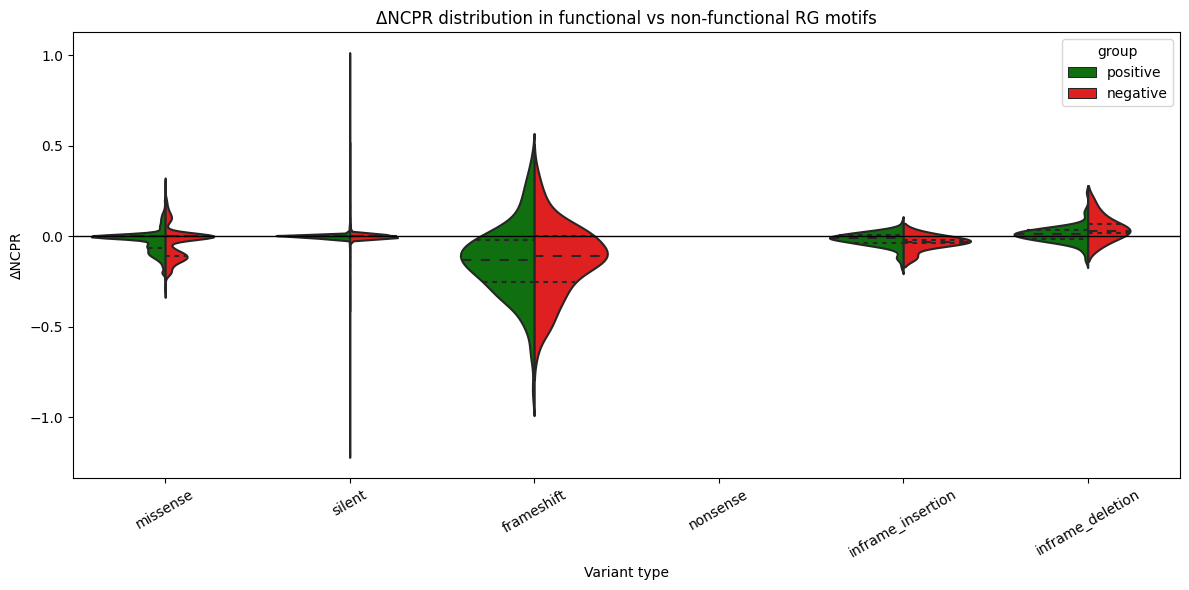

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

df = variant_info_df.copy()
df["delta_RG"] = df["gained"] - df["lost"]

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="variant_type",          # or: variant_mech
    y="NCPR_change",
    hue="group",               # positive vs negative
    split=True,
    inner="quartile",
    palette={"positive":"green", "negative":"red"}
)

plt.axhline(0, color="black", lw=1)
plt.title("ΔNCPR distribution in functional vs non-functional RG motifs")
plt.ylabel("ΔNCPR")
plt.xlabel("Variant type")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


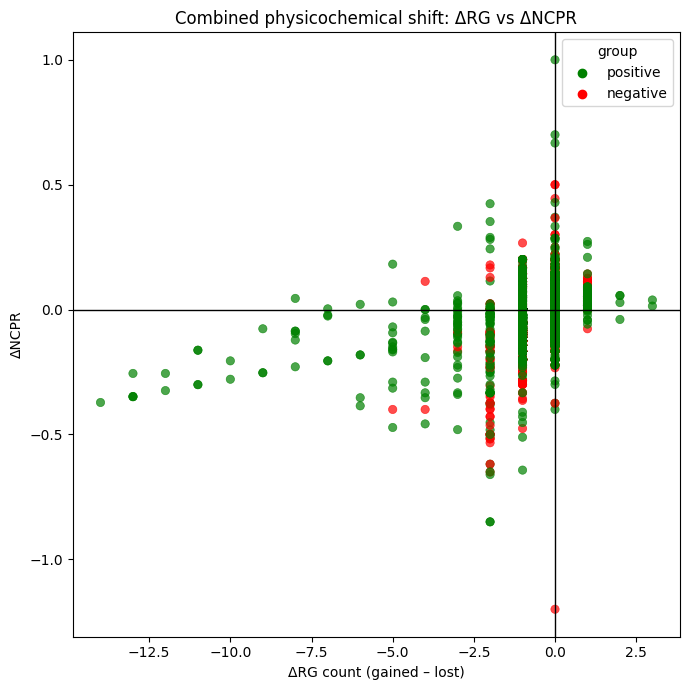

In [12]:
plt.figure(figsize=(7,7))

sns.scatterplot(
    data=df,
    x="delta_RG",
    y="NCPR_change",
    hue="group",
    palette={"positive":"green", "negative":"red"},
    alpha=0.7,
    edgecolor=None
)

plt.axhline(0, color="black", lw=1)
plt.axvline(0, color="black", lw=1)

plt.xlabel("ΔRG count (gained – lost)")
plt.ylabel("ΔNCPR")
plt.title("Combined physicochemical shift: ΔRG vs ΔNCPR")

plt.tight_layout()
plt.show()


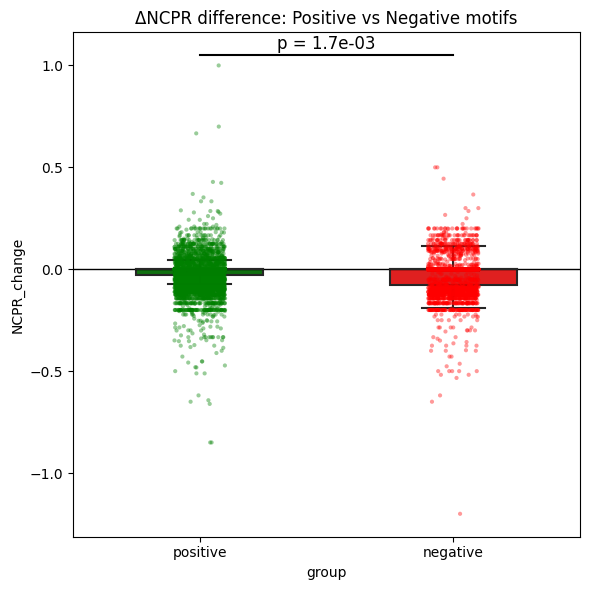

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import numpy as np

df = variant_info_df.copy()
df["delta_RG"] = df["gained"] - df["lost"]

# Statistical test
pos_vals = df[df.group=="positive"]["NCPR_change"].dropna()
neg_vals = df[df.group=="negative"]["NCPR_change"].dropna()

stat, pval = mannwhitneyu(pos_vals, neg_vals, alternative="two-sided")

# ------- Plot -------
plt.figure(figsize=(6,6))

sns.boxplot(
    data=df, x="group", y="NCPR_change",
    palette={"positive":"green", "negative":"red"},
    width=0.5, showfliers=False
)

sns.stripplot(
    data=df, x="group", y="NCPR_change",
    palette={"positive":"green", "negative":"red"},
    dodge=True, alpha=0.4, size=3
)

# Add statistical annotation
ymax = df["NCPR_change"].max()
ypos = ymax * 1.05
plt.plot([0,1],[ypos,ypos], color="black")
plt.text(0.5, ypos*1.01, f"p = {pval:.1e}", ha="center", va="bottom", fontsize=12)

plt.axhline(0, color="black", lw=1)
plt.title("ΔNCPR difference: Positive vs Negative motifs")

plt.tight_layout()
plt.show()


In [35]:
df = variant_info_df.copy()

In [38]:
silent_variants = df[df["variant_type"] == "silent"]

silent_variants[silent_variants["REF"] != silent_variants["ALT"]]

,Chromosome,Start,ID,REF,ALT,QUAL,FILTER,AC_joint,AN_joint,AF_joint,...,gained,lost,unchanged,NCPR_change,FCR_change,hydropathy_change,kappa_change,pos_count_change,neg_count_change,aromaticity_change
1,chr1,7784883,.,C,T,.,PASS,2,1508626,1.325710e-06,...,0,0,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
9,chr1,7784886,.,C,T,.,PASS,79,1509526,5.233430e-05,...,0,0,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
15,chr1,7784889,.,G,A,.,EXOMES_FILTERED,0,1513286,0.000000e+00,...,0,0,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
16,chr1,7784892,.,A,G,.,EXOMES_FILTERED,2,1514658,1.320430e-06,...,0,0,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
20,chr1,7784895,.,T,C,.,EXOMES_FILTERED,0,1519270,0.000000e+00,...,0,0,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14231,chr22,29299827,.,G,GTGGAGGACC,.,PASS,1,1554082,6.434670e-07,...,0,0,2,-0.083333,-0.083333,0.241667,0.136679,0.0,0.0,0.0
14232,chr22,29299828,.,T,C,.,PASS,2,1550974,1.289510e-06,...,0,0,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
14233,chr22,29299830,.,G,GAGGACC,.,PASS,5,1551652,3.222370e-06,...,0,0,2,-0.060606,-0.060606,0.139394,0.093307,0.0,0.0,0.0
14234,chr22,29299831,.,A,G,.,EXOMES_FILTERED,0,1551256,0.000000e+00,...,0,0,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0


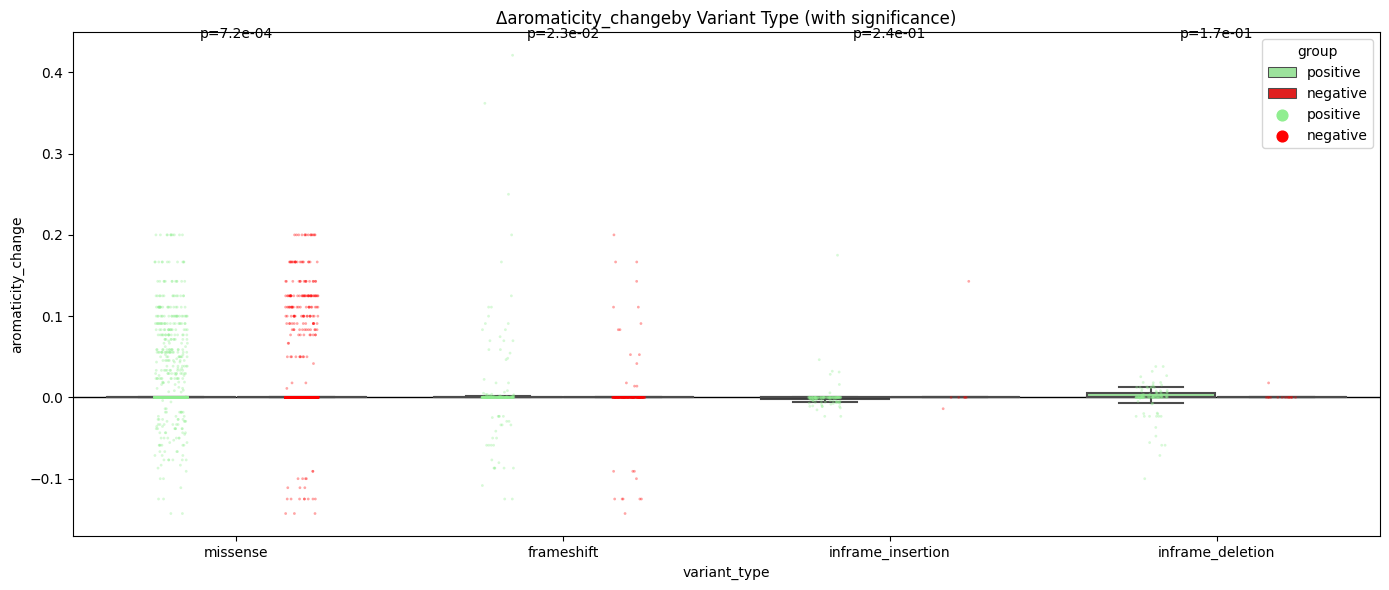

In [45]:
import itertools
from scipy.stats import mannwhitneyu

# variant_types = df["variant_type"].dropna().unique()
# print(variant_types)
# variant_types = list(variant_types)
# variant_types.remove("silent")
# variant_types.remove("nonsense")
# print(variant_types)
features = [
    'NCPR_change', 'FCR_change', 'hydropathy_change',
    'kappa_change', 'pos_count_change', 'neg_count_change',
    'aromaticity_change'
]
physchem_feat = features[6]


df = df[df["variant_type"].isin(variant_types)]

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df, x="variant_type", y=physchem_feat,
    hue="group",
    palette={"positive":"lightgreen", "negative":"red"},
    showfliers=False
)

sns.stripplot(
    data=df, x="variant_type", y=physchem_feat,
    hue="group",
    palette={"positive":"lightgreen", "negative":"red"},
    dodge=True, alpha=0.35, size=2
)

# Add stats per type
ax = plt.gca()
ymax = df[physchem_feat].max()

for i, vt in enumerate(variant_types):
    pos_vals = df[(df.variant_type==vt) & (df.group=="positive")][physchem_feat].dropna()
    neg_vals = df[(df.variant_type==vt) & (df.group=="negative")][physchem_feat].dropna()

    if len(pos_vals)>0 and len(neg_vals)>0:
        stat, pval = mannwhitneyu(pos_vals, neg_vals, alternative="two-sided")
    else:
        pval = np.nan

    ypos = ymax + (0.05 * ymax)
    ax.text(i, ypos, f"p={pval:.1e}", ha="center")

plt.axhline(0, color="black", lw=1)
plt.title(str("Δ" + physchem_feat  + "by Variant Type (with significance)"))
plt.tight_layout()
plt.show()


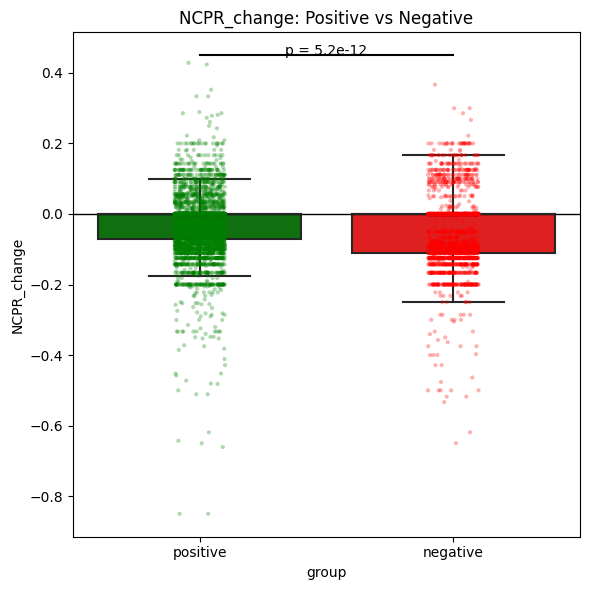

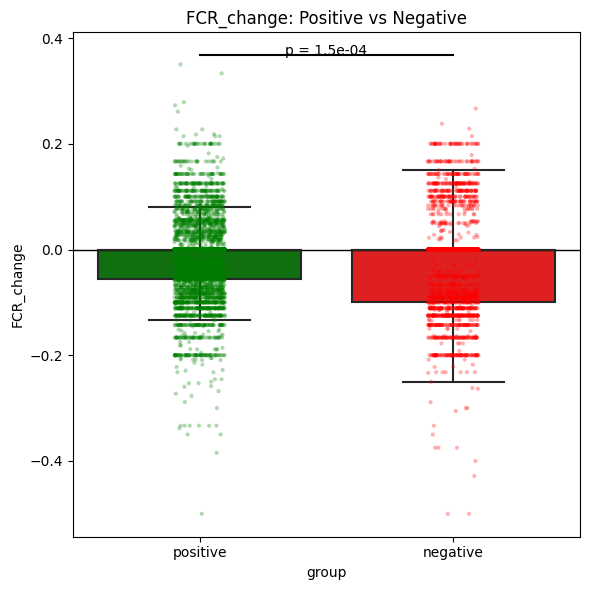

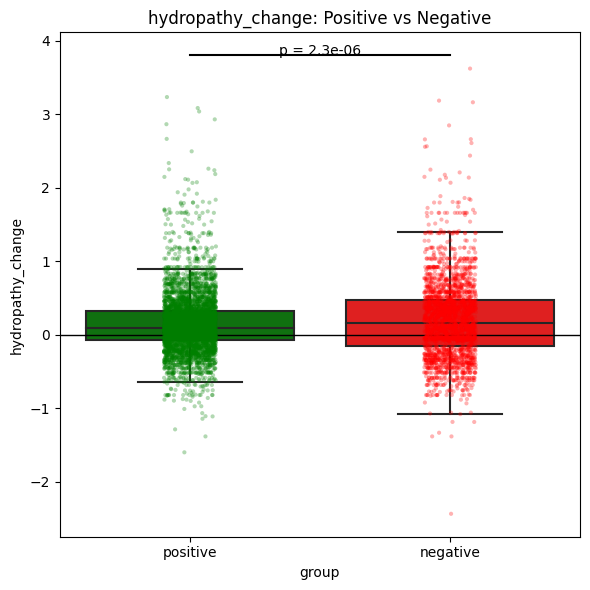

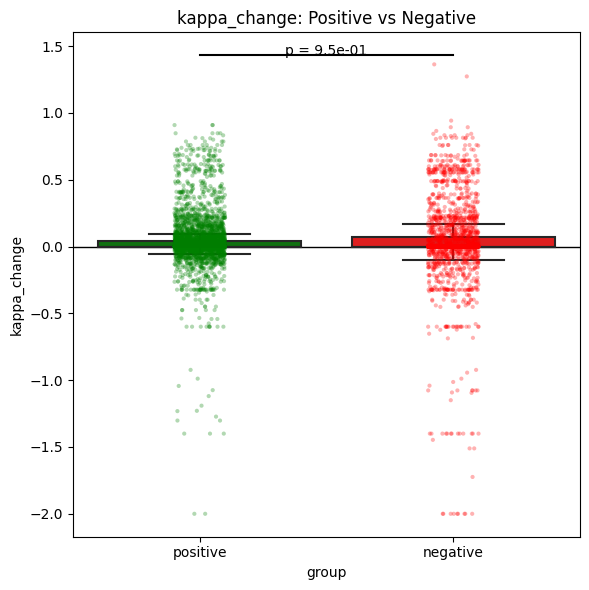

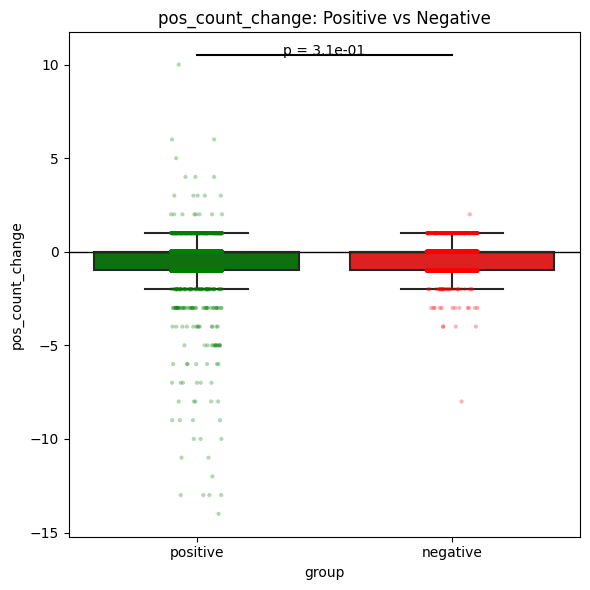

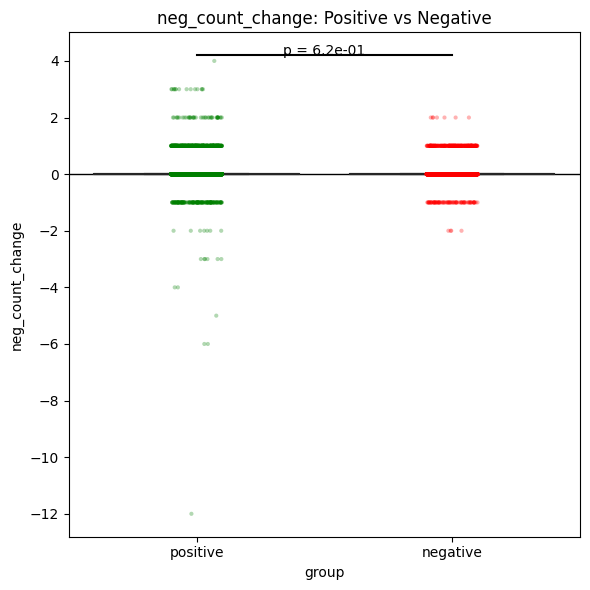

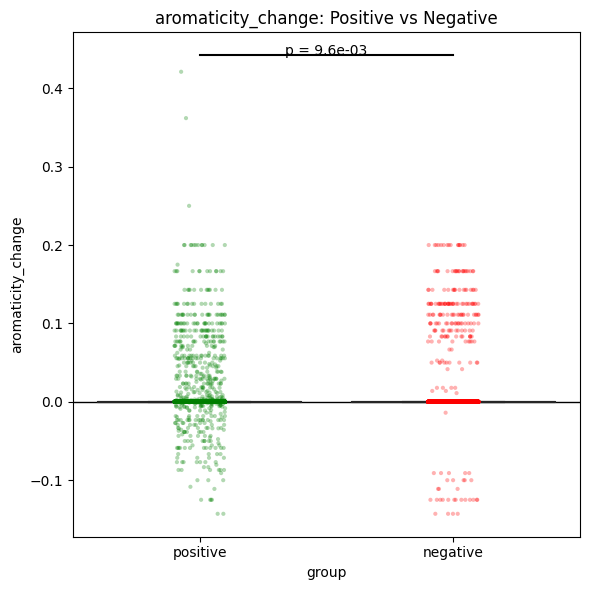

In [28]:
features = [
    'NCPR_change', 'FCR_change', 'hydropathy_change',
    'kappa_change', 'pos_count_change', 'neg_count_change',
    'aromaticity_change'
]

for feat in features:
    plt.figure(figsize=(6,6))

    sns.boxplot(
        data=df, x="group", y=feat,
        palette={"positive":"green", "negative":"red"},
        showfliers=False
    )

    sns.stripplot(
        data=df, x="group", y=feat,
        palette={"positive":"green", "negative":"red"},
        dodge=True, alpha=0.3, size=3
    )

    pos_vals = df[df.group=="positive"][feat].dropna()
    neg_vals = df[df.group=="negative"][feat].dropna()
    stat, pval = mannwhitneyu(pos_vals, neg_vals)

    ymax = df[feat].max()
    ypos = ymax * 1.05

    plt.plot([0,1], [ypos, ypos], color="black")
    plt.text(0.5, ypos, f"p = {pval:.1e}", ha="center")

    plt.axhline(0, color="black", lw=1)
    plt.title(f"{feat}: Positive vs Negative")
    plt.tight_layout()
    plt.show()
